In [1]:
# how to uncover truths that don't matter - third section

In [2]:
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import pandas as pd
from sklearn.linear_model import LinearRegression

In [3]:
import coriolis_functions
import coriolis_module

In [4]:
# loading dataframe with not cancelled flights
fdf = pd.read_csv("data/coriolis_flights_3m.csv", sep=";").astype(
    {
        "FL_DATE": "datetime64[ns]", 
        "AIRLINE": "category", 
        "AIRLINE_DOT": "category", 
        "AIRLINE_CODE": "category", 
        "ORIGIN": "category", 
        "ORIGIN_CITY": "category", 
        "DEST": "category",
        "DEST_CITY": "category", 
        "CANCELLED": "bool",
        "CANCELLATION_CODE": "category", 
        "DIVERTED": "bool",
    }
)

In [5]:
ldf = pd.read_csv("data/airports.csv").astype(
    {
        "IATA": "category",
        "AIRPORT": "category",
        "CITY": "category",
        "STATE": "category",
        "COUNTRY": "category",
    }
)

In [6]:
# checking unique values in both datasets
fdf_airports = set(fdf["ORIGIN"].unique()).union(set(fdf["DEST"].unique()))
ldf_airports = set(ldf["IATA"].unique())  

# finding missing airport codes in ldf
missing_airports = fdf_airports.difference(ldf_airports)

# dropping rows where "ORIGIN" or "DEST" are in missing_airports
fdf = fdf[~fdf["ORIGIN"].isin(missing_airports) & ~fdf["DEST"].isin(missing_airports)]

# merging fdf with ldf to add geographical data for ORIGIN and DEST
fdf = pd.merge(fdf, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="ORIGIN", right_on="IATA", how="left")

fdf = pd.merge(fdf, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="DEST", right_on="IATA", how="left", suffixes=("_ORIGIN", "_DEST"))

# dropping original origin and destination columns
fdf = fdf.drop(["ORIGIN", "DEST"], axis=1)

# enforcing categories on newly generated columns
fdf[["IATA_ORIGIN", "IATA_DEST"]] = fdf[["IATA_ORIGIN", "IATA_DEST"]].astype("category")

In [7]:
# defining time columns
time_columns = ["ARR_TIME", "DEP_TIME", "WHEELS_OFF", "WHEELS_ON", "CRS_ARR_TIME", "CRS_DEP_TIME"]

# defining a helper function
def convert_time(df, time_columns):
    """ Convert integer time columns to HH:MM format """
    for col in time_columns:
        # Handle missing values and convert times
        df[col] = df[col].fillna(0).astype(int).apply(lambda x: f"{x//100:02d}:{x%100:02d}")
        # Adjust for hours == 24
        df[col] = df[col].replace("24:00", "00:00")
    return df

# applying the time conversion
fdf = convert_time(fdf, time_columns)

# Combine dates and times into datetime
fdf["arr_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["ARR_TIME"])
fdf["dep_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["DEP_TIME"])

fdf["crs_arr_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["CRS_ARR_TIME"])
fdf["crs_dep_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["CRS_DEP_TIME"])

fdf["woff_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["WHEELS_OFF"])
fdf["won_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["WHEELS_ON"])

# dropping original time columns
fdf = fdf.drop(time_columns, axis=1)

# calculating haversinedistance
fdf["haversine_distance"] = coriolis_functions.haversine(
    fdf["LATITUDE_ORIGIN"],
    fdf["LONGITUDE_ORIGIN"],
    fdf["LATITUDE_DEST"], 
    fdf["LONGITUDE_DEST"]
)

# division of drift through distance gives percentage
fdf.loc[:, "drift_factor"] = fdf["total_drift_distance"] / fdf["haversine_distance"].replace(0, pd.NA)

# setting up airtime and average velocity columns
fdf["airtime"] = fdf["won_datetime"] - fdf["woff_datetime"]
fdf["average_velocity"] = fdf["haversine_distance"] / fdf["airtime"].dt.total_seconds()

In [8]:
fdf.dtypes

FL_DATE                     datetime64[ns]
AIRLINE                           category
AIRLINE_DOT                       category
AIRLINE_CODE                      category
DOT_CODE                             int64
FL_NUMBER                            int64
ORIGIN_CITY                       category
DEST_CITY                         category
DEP_DELAY                          float64
TAXI_OUT                           float64
TAXI_IN                            float64
ARR_DELAY                          float64
CANCELLED                             bool
CANCELLATION_CODE                 category
DIVERTED                              bool
CRS_ELAPSED_TIME                   float64
ELAPSED_TIME                       float64
AIR_TIME                           float64
DISTANCE                           float64
DELAY_DUE_CARRIER                  float64
DELAY_DUE_WEATHER                  float64
DELAY_DUE_NAS                      float64
DELAY_DUE_SECURITY                 float64
DELAY_DUE_L

In [9]:
# cleaning data for machiene learning (linear regression and fitting polynomials)

In [10]:
print("number of rows before further cleaning: ", rows_before_cleaning := len(fdf))

number of rows before further cleaning:  2948087


In [11]:
fdf_cleaned = fdf.dropna(subset=["DEP_DELAY", "ARR_DELAY"])

In [12]:
print("number of rows after cleaning: ", len(fdf_cleaned))
print("number of rows lost due cleaning: ", rows_before_cleaning - len(fdf_cleaned))

number of rows after cleaning:  2863927
number of rows lost due cleaning:  84160


In [13]:
# linear regression in numpy is identical to fitting a polynomial of order one.

In [14]:
# linear regression using numpy
m, b = np.polyfit(fdf_cleaned["DEP_DELAY"], fdf_cleaned["ARR_DELAY"],1 )

In [15]:
# printing slope and intercept calculated with numpy
print("Slope by numpy (m): ", m)
print("Intercept by numpy (b): ", b)

Slope by numpy (m):  1.0065963634969837
Intercept by numpy (b):  -5.910520810137672


In [16]:
# and calculate R²
poly = np.poly1d([m, b])
y_predictions = poly(fdf_cleaned["DEP_DELAY"])

ss_res = np.sum((fdf_cleaned["ARR_DELAY"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf_cleaned["ARR_DELAY"] - np.mean(fdf_cleaned["ARR_DELAY"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)
                
print(f"Coefficients for polynomial: m = {m}; b = {b}")
print("R² of the polynomial: ", poly_r_squared)

Coefficients for polynomial: m = 1.0065963634969837; b = -5.910520810137672
R² of the polynomial:  0.9299746284939273


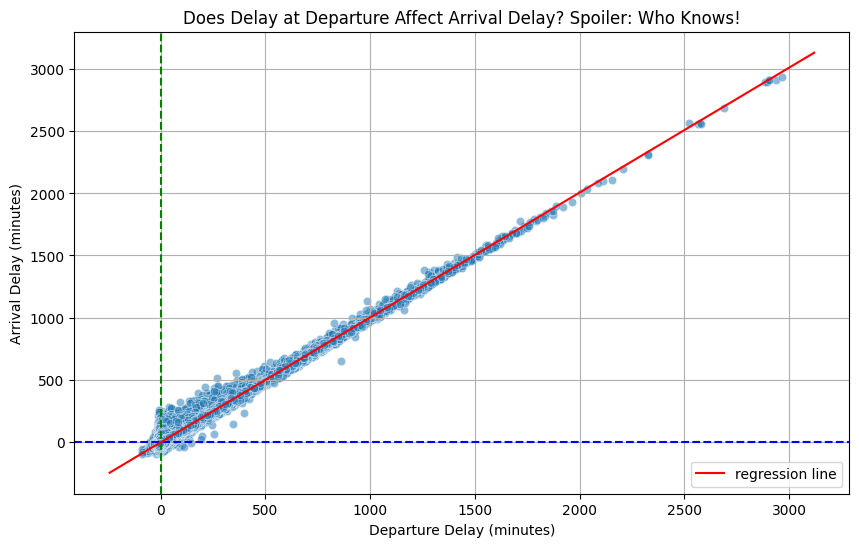

In [17]:
# plotting linear regression of our first question
plt.figure(figsize=(10, 6))
sns.scatterplot(x="DEP_DELAY", y="ARR_DELAY", data=fdf_cleaned, alpha=0.5)

plt.title("Does Delay at Departure Affect Arrival Delay? Spoiler: Who Knows!")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for on-time arrivals
plt.axvline(0, color="green", linestyle="--")  # Reference line for on-time departures

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = b + m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.legend(loc="lower right")
plt.show()

Slope by scikit-learn (m):  1.0065963634969832
Intercept by scikit-learn (b):  -5.91052081013766
R² by scikit-learn:  0.9299746284939273


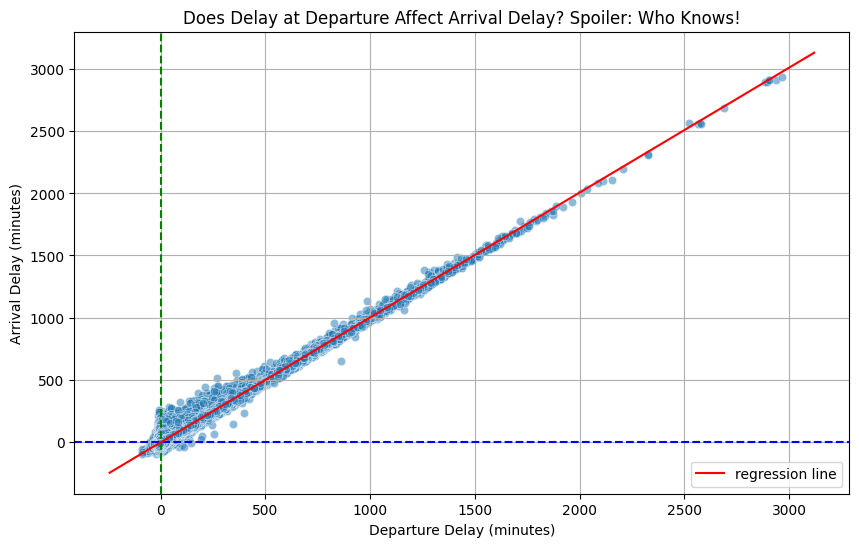

In [18]:
# linear regression using scikit-learn
X = fdf_cleaned["DEP_DELAY"].values.reshape(-1, 1)
Y = fdf_cleaned["ARR_DELAY"].values

model = LinearRegression()
model.fit(X, Y)

m = model.coef_[0]
b = model.intercept_
r_squared = model.score(X, Y)

print("Slope by scikit-learn (m): ", m)
print("Intercept by scikit-learn (b): ", b)
print("R² by scikit-learn: ", r_squared)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="DEP_DELAY", y="ARR_DELAY", data=fdf_cleaned, alpha=0.5)

plt.title("Does Delay at Departure Affect Arrival Delay? Spoiler: Who Knows!")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = b + m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.legend(loc="lower right")
plt.show()

In [19]:
# resetting cleaned dataframe 
fdf_cleaned = fdf
# printing number of before rows 
print("number of rows before cleaning: ", rows_before_cleaning := len(fdf_cleaned))
# clean up for other model
fdf_cleaned.dropna(subset=["total_drift_distance", "haversine_distance"], inplace=True)
# printing number of rows after cleaning
print("number of rows after cleaning: ", len(fdf_cleaned))
print("number of rows lost due cleaning: ", rows_before_cleaning - len(fdf_cleaned))

number of rows before cleaning:  2948087
number of rows after cleaning:  2730145
number of rows lost due cleaning:  217942


Slope by scikit-learn (m):  0.5436601401903043
Intercept by scikit-learn (b):  -358.0336996805926
R² by scikit-learn:  0.5896996724622686


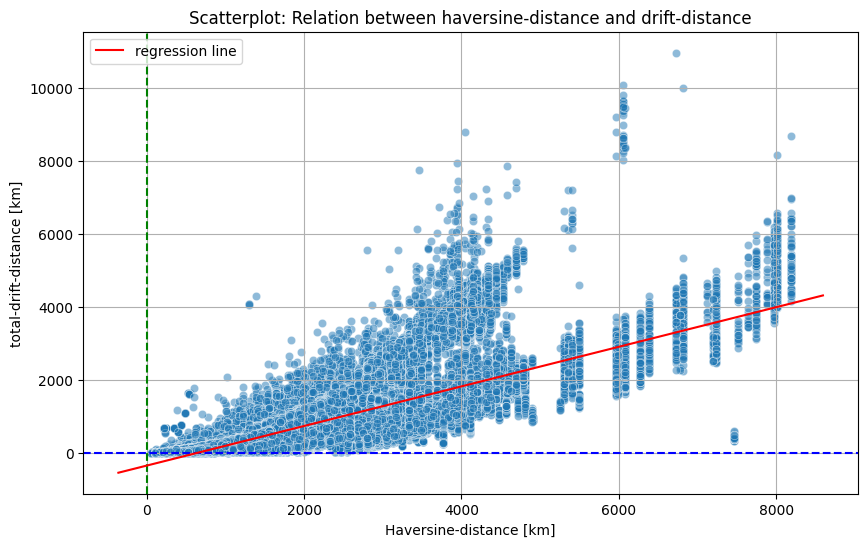

In [20]:
# linear regression using scikit-learn
X = fdf_cleaned["haversine_distance"].values.reshape(-1, 1)
Y = fdf_cleaned["total_drift_distance"].values

model = LinearRegression()
model.fit(X, Y)

scikit_m = model.coef_[0]
scikit_b = model.intercept_
r_squared = model.score(X, Y)

print("Slope by scikit-learn (m): ", scikit_m)
print("Intercept by scikit-learn (b): ", scikit_b)
print("R² by scikit-learn: ", r_squared)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf_cleaned, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-distance")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = scikit_b + scikit_m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.legend(loc="upper left")
plt.show()

Coefficients for polynomial:  [ 1.07473656e-04  1.25354763e-01 -8.72480070e+01]
R² of the polynomial:  0.6382549327701649


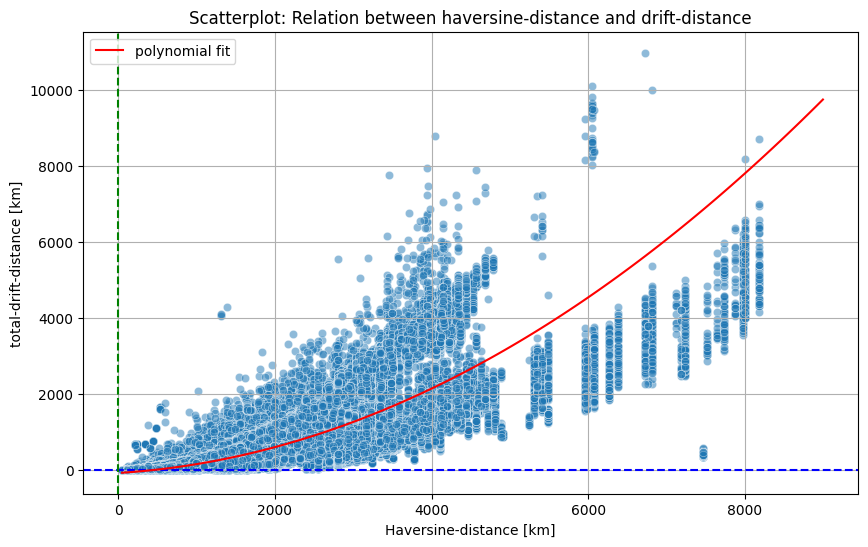

In [21]:
# let's try a scond order polynomial and calculate R² along the way
coefs = np.polyfit(fdf_cleaned["haversine_distance"], fdf_cleaned["total_drift_distance"], 2)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf_cleaned["haversine_distance"])

ss_res = np.sum((fdf_cleaned["total_drift_distance"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf_cleaned["total_drift_distance"] - np.mean(fdf_cleaned["total_drift_distance"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)
                
print("Coefficients for polynomial: ", coefs)
print("R² of the polynomial: ", poly_r_squared)

# setup polynomial for plot
poly_x_vals = np.linspace(fdf_cleaned["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
poly_y_vals = np.polyval(coefs, poly_x_vals)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf_cleaned, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-distance")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# plotting polynomial
plt.plot(poly_x_vals, poly_y_vals, color="red", label="polynomial fit")

plt.grid(True)
plt.legend(loc="upper left")
plt.show()

0. coef for polynomial:  4.127651497877106e-15
1. coef for polynomial:  -6.883714012404335e-11
2. coef for polynomial:  3.5655414250226856e-07
3. coef for polynomial:  -0.0005526802180796223
4. coef for polynomial:  0.4673533548464198
5. coef for polynomial:  -84.34544989571879
R² of the polynomial:  0.6719692060185782


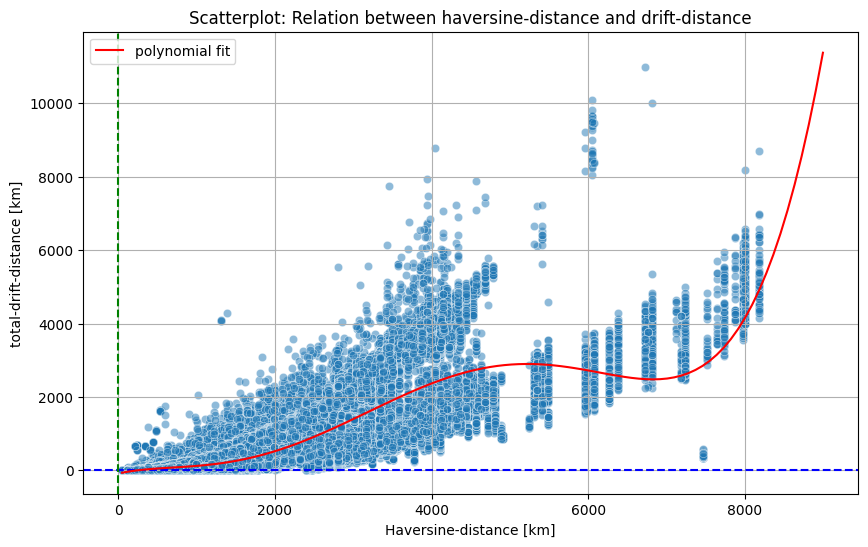

In [22]:
# let's try a fifth order polynomial and calculate R² along the way
coefs = np.polyfit(fdf_cleaned["haversine_distance"], fdf_cleaned["total_drift_distance"], 5)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf_cleaned["haversine_distance"])

ss_res = np.sum((fdf_cleaned["total_drift_distance"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf_cleaned["total_drift_distance"] - np.mean(fdf_cleaned["total_drift_distance"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)

for i, coefficient in enumerate(coefs):
    print(f"{i}. coef for polynomial: ", coefficient)
print("R² of the polynomial: ", poly_r_squared)

# setup polynomial for plot
poly_x_vals = np.linspace(fdf_cleaned["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
poly_y_vals = np.polyval(coefs, poly_x_vals)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf_cleaned, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-distance")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# plotting polynomial
plt.plot(poly_x_vals, poly_y_vals, color="red", label="polynomial fit")

plt.grid(True)
plt.legend(loc="upper left")
plt.show()

/home/jnja/cs/.venvs/ds/lib64/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


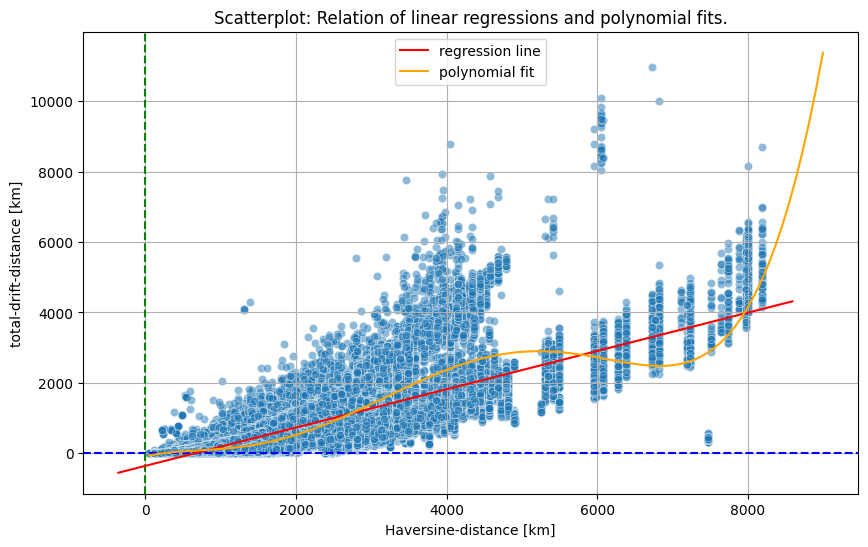

In [23]:
# let's compare and figure out the questions later!
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf_cleaned, alpha=0.5)

plt.title("Scatterplot: Relation of linear regressions and polynomial fits.")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = scikit_b + scikit_m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

# adding polynomial for plot
plt.plot(poly_x_vals, poly_y_vals, color="orange", label="polynomial fit")

plt.grid(True)
plt.legend()
plt.show()

Coefficients for polynomial:  [ 0.00013883 -0.00311325]
R² of the polynomial:  0.44626895706156644


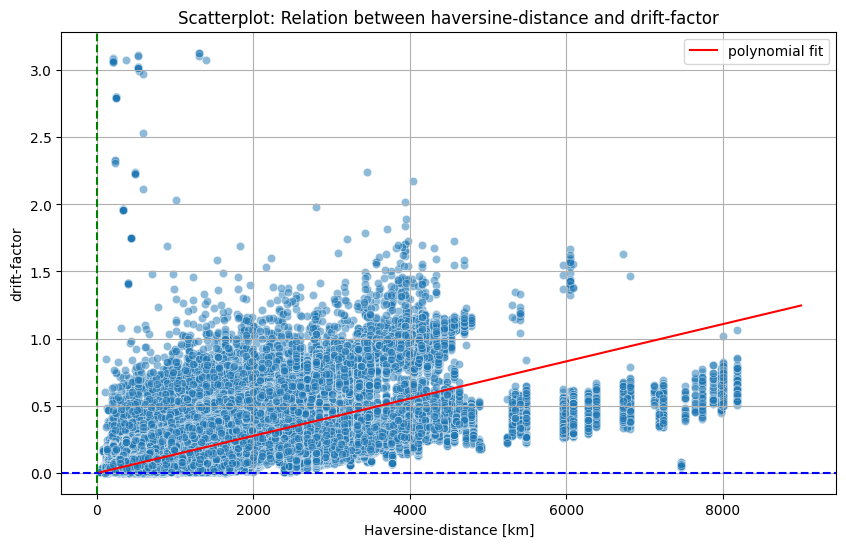

In [24]:
# let's try a linear regression and calculate R² along the way
coefs = np.polyfit(fdf_cleaned["haversine_distance"], fdf_cleaned["drift_factor"], 1)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf_cleaned["haversine_distance"])

ss_res = np.sum((fdf_cleaned["drift_factor"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf_cleaned["drift_factor"] - np.mean(fdf_cleaned["drift_factor"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)

                
print("Coefficients for polynomial: ", coefs)
print("R² of the polynomial: ", poly_r_squared)

# setup polynomial for plot
poly_x_vals = np.linspace(fdf_cleaned["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
poly_y_vals = np.polyval(coefs, poly_x_vals)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="drift_factor", data=fdf_cleaned, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-factor")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("drift-factor")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# plotting polynomial
plt.plot(poly_x_vals, poly_y_vals, color="red", label="polynomial fit")

plt.grid(True)
plt.legend(loc="upper right")
plt.show()

0. coef for polynomial:  9.382066437456826e-19
1. coef for polynomial:  -1.456351617211794e-14
2. coef for polynomial:  6.745772646940738e-11
3. coef for polynomial:  -9.629351186732438e-08
4. coef for polynomial:  0.00014178255491778096
5. coef for polynomial:  0.025291177418085904
R² of the polynomial:  0.4662678555991919


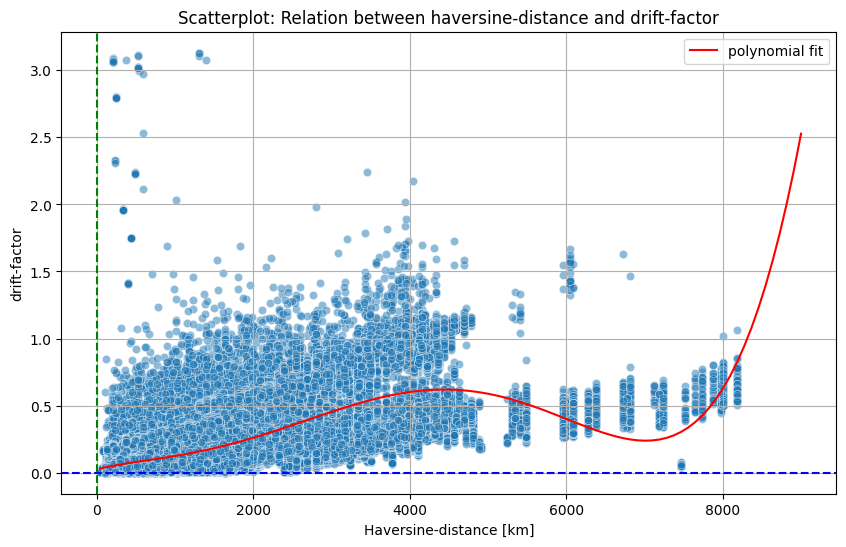

In [25]:
# let's try a fith order polynomial and calculate R² along the way
coefs = np.polyfit(fdf_cleaned["haversine_distance"], fdf_cleaned["drift_factor"], 5)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf_cleaned["haversine_distance"])

ss_res = np.sum((fdf_cleaned["drift_factor"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf_cleaned["drift_factor"] - np.mean(fdf_cleaned["drift_factor"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)

for i, coefficient in enumerate(coefs):
    print(f"{i}. coef for polynomial: ", coefficient)
print("R² of the polynomial: ", poly_r_squared)

# setup polynomial for plot
poly_x_vals = np.linspace(fdf_cleaned["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
poly_y_vals = np.polyval(coefs, poly_x_vals)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="drift_factor", data=fdf_cleaned, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-factor")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("drift-factor")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# plotting polynomial
plt.plot(poly_x_vals, poly_y_vals, color="red", label="polynomial fit")

plt.grid(True)
plt.legend(loc="upper right")
plt.show()

Slope by scikit-learn (m):  0.00013883219706493113
Intercept by scikit-learn (b):  -0.0031132482456129595
R² by scikit-learn:  0.44626895706156644


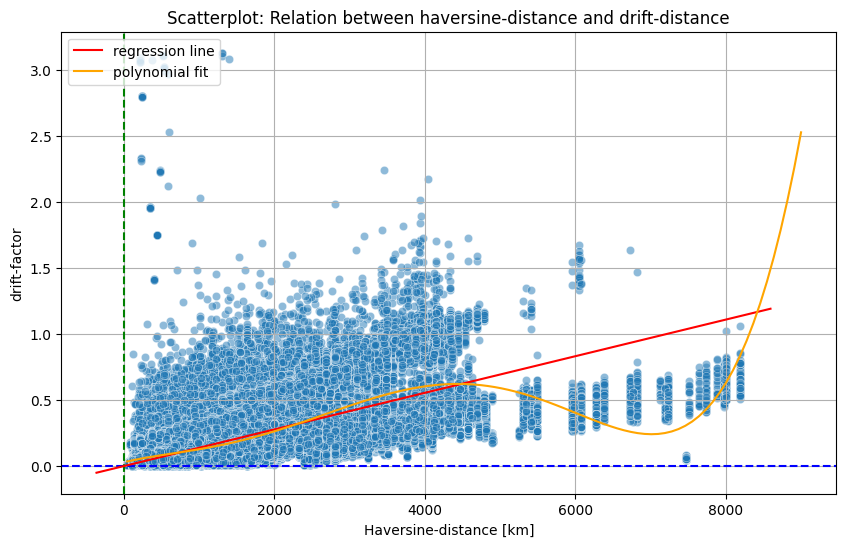

In [27]:
# linear regression using scikit-learn
X = fdf_cleaned["haversine_distance"].values.reshape(-1, 1)
Y = fdf_cleaned["drift_factor"].values

model = LinearRegression()
model.fit(X, Y)

scikit_m = model.coef_[0]
scikit_b = model.intercept_
r_squared = model.score(X, Y)

print("Slope by scikit-learn (m): ", scikit_m)
print("Intercept by scikit-learn (b): ", scikit_b)
print("R² by scikit-learn: ", r_squared)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="drift_factor", data=fdf_cleaned, alpha=0.5)

plt.title("Scatterplot: Relation between haversine-distance and drift-distance")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("drift-factor")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = scikit_b + scikit_m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")
# adding polynomial for plot
plt.plot(poly_x_vals, poly_y_vals, color="orange", label="polynomial fit")

plt.grid(True)
plt.legend(loc="upper left")
plt.show()